# Is the test of vertical transmission valid under both Model 1 and Model 2?

**The claim.** The likelihood-ratio test of no vertical transmission (H0: f = 0) is valid whether Model 1 or Model 2 is fit, whatever the type of assortative mating (AM), and whether or not the trait has a latent genetic component that the PGS does not capture (Model 1 assumes it has none). So if f is significant under one model, it should be significant under the other.

**Short answer: the claim does not hold in general.** It fails exactly where it matters most in practice, when the PGS captures only part of the heritability and spouses assort on the phenotype (primary AM) or on genetic value (genetic homogamy).

- **Model 2 Cascade**, the correctly specified model, gives a valid test everywhere. Under f = 0 its LRT is centred on its χ²₁ null distribution in all 8 conditions, and it rejected in 7 of 160 Monte Carlo datasets (4.4%).
- **Model 1, in both versions**, is invalid when the trait has a latent genetic score and AM is primary or genetic homogamy. With f = 0 it estimates f ≈ 0.10–0.20 and rejects f = 0 in every dataset (40 of 40). The noncentrality grows with the number of trios n, so the false-positive rate is already about 63% (primary AM) and 99% (genetic homogamy) at 1,000 trios.
- **Model 1 is valid when its assumptions hold:** random mating, or a PGS that captures all of the heritability. It is also valid under social homogamy, where AM leaves no PGS–latent covariance when f = 0. One exception: the Cascade version of Model 1 under social homogamy rejects too often, because its µ is not identified when f = 0 (Section 2).
- **Even when both tests are valid they need not agree.** Model 2 Cascade has much less power, so at small effects Model 1 is significant and Model 2 is not (Section 3).

The scripts are `conditions.R` (shared setup), `01_population_lrt.R` (exact population values) and `02_monte_carlo.R` (simulated datasets); this notebook only reads their outputs in `output/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

OUT = Path("output")
pop = pd.read_csv(OUT / "population_lrt.csv")
mc  = pd.read_csv(OUT / "mc_results.csv")

MODELS = ["M2_Cascade", "M1_Cascade", "M1"]
LABEL  = {"M2_Cascade": "Model 2 Cascade", "M1_Cascade": "Model 1 Cascade", "M1": "Model 1"}
COLOR  = {"M2_Cascade": "#2a78d6", "M1_Cascade": "#eb6834", "M1": "#1baf7a"}   # reference palette slots 1-3
INK, INK2, RULE = "#0b0b0b", "#52514e", "#dcdad5"
MATING = ["none", "primary", "genetic", "social"]
MLAB   = {"none": "random mating", "primary": "primary phenotypic AM", "genetic": "genetic homogamy",
          "social": "social homogamy"}
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": RULE,
                     "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": RULE,
                     "grid.linewidth": .6, "font.size": 10, "legend.frameon": False})
pd.set_option("display.width", 160, "display.max_columns", 30)

def condLabel(mating, latent):
    return f"{MLAB[mating]}, {'latent genetic score' if latent else 'PGS = all heritability'}"

def wilson(k, n, z=1.96):
    p = k / n; d = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / d; h = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return np.clip(c - h, 0, 1), np.clip(c + h, 0, 1)

mc["sig"] = mc["p"] < .05
print(f"{mc[['cond', 'n', 'rep']].drop_duplicates().shape[0]} Monte Carlo datasets, {len(mc)} model fits")

320 Monte Carlo datasets, 960 model fits


## How the test is set up

**Data-generating model.** The equilibrium SEM-PGS Cascade model for a continuous trait, built with the Cascade iterative math. That math was checked against GeneEvolve simulations in `OpenMxScripts_Cascade/Validation`. The parents' phenotypic variance is scaled to 1 in every condition.

**Conditions (24).**

| Factor | Levels |
|---|---|
| Mating | random mating (no AM); primary phenotypic AM; genetic homogamy; social homogamy (mate correlation .4 on the mating phenotype) |
| Latent genetic score | absent: the PGS carries all of the base-population genetic variance (δ² = .5, a = 0), so Model 1's assumption holds; present: δ² = .2 in the PGS and a² = .3 latent |
| True f | 0 (for the type I error), .05 and .15 (for the power) |

**Models fit to every dataset.**

| Model | Script | Data | Specification |
|---|---|---|---|
| Model 2 Cascade | `UniSEMPGS_Cascade_SameTrait_ObservedYPYM.R` | parents' and offspring phenotypes, 4 haplotypic PGS | latent genetic score modelled; mating mechanism estimated. **Correct in every condition.** |
| Model 1 Cascade | `UniSEMPGS_Cascade_Model1.R` | offspring phenotype, 4 haplotypic PGS | no latent genetic score; mating mechanism fixed at the true one |
| Model 1 | `UniSEMPGS_Model1.R` | offspring phenotype, 4 haplotypic PGS | no latent genetic score; primary phenotypic AM assumed |

**The test.** For each model, `mxCompare(free-f fit, f = 0 fit)` gives a 1-df likelihood-ratio test, with α = .05. Each fit is the scripts' own model; the harness only takes over the call to `mxTryHard`.

The free fit is run from six starting values of f, and both fits are reseeded from each other. This guarantees −2LL(free) ≤ −2LL(f = 0) and protects against local optima. It matters: Model 1 Cascade's likelihood under social homogamy has several optima, and an earlier single-start run missed some of them.

Model 2 Cascade starts at the generating values, as is usual in Monte Carlo studies. The Model 1 scripts start from their own sample-moment values.

**Two sources of numbers.**

1. **Exact population values** (`01_population_lrt.R`). Each condition's population covariance is fit exactly. The resulting LRT is the noncentrality λ of the test at n = 10,000. Under a valid test, λ = 0 when f = 0. Because λ scales with n, the expected rejection rate at any sample size is P(χ²₁(λ·n/10,000) > 3.84). These are the precise rates.
2. **Monte Carlo** (`02_monte_carlo.R`). 10 datasets per cell, drawn from the population covariance with sampling noise: f = 0 at n = 2,000 and n = 10,000, and f > 0 at n = 10,000. This is a finite-sample check of the population results. With 10 datasets one rejection moves a rate by 0.10, so single cells are noisy, and pooled counts are quoted where it matters.

The table below lists the true values. i is the AM-induced covariance between the PGS and the latent genetic score. Model 1 has no term for it, and it is what breaks Model 1's test.

In [2]:
d = pop[pop.model == "M2_Cascade"].copy()
d["condition"] = [condLabel(m, l) for m, l in zip(d.mating, d.latent)]
d = d[["condition", "f", "mu_true", "gt_true", "ic_true", "VF_true"]].rename(columns={
    "f": "true f", "mu_true": "mu", "gt_true": "g (PGS-PGS)", "ic_true": "i (PGS-latent)", "VF_true": "VF"})
d.round(4).set_index("condition")

,true f,mu,g (PGS-PGS),i (PGS-latent),VF
condition,,,,,
"random mating, PGS = all heritability",0.00,0.0000,0.0000,0.0000,0.0000
"primary phenotypic AM, PGS = all heritability",0.00,0.4000,0.0727,0.0000,0.0000
"genetic homogamy, PGS = all heritability",0.00,0.6400,0.1667,0.0000,0.0000
"social homogamy, PGS = all heritability",0.00,0.8000,0.0000,0.0000,0.0000
"random mating, latent genetic score",0.00,0.0000,0.0000,0.0000,0.0000
"primary phenotypic AM, latent genetic score",0.00,0.4000,0.0291,0.0356,0.0000
"genetic homogamy, latent genetic score",0.00,0.6400,0.0667,0.0816,0.0000
"social homogamy, latent genetic score",0.00,0.8000,0.0000,0.0000,0.0000
"random mating, PGS = all heritability",0.05,0.0000,0.0000,0.0000,0.0050


## 1. Where each model's estimate of f converges, and the noncentrality of its test

These are exact population values: no sampling noise. Reading the three tables:

- **Model 2 Cascade** recovers the true f in all 24 conditions, and its λ is 0 whenever f = 0. Its test is valid.
- **Model 1, in both versions,** also has λ = 0 at f = 0 in six of the eight conditions. That includes social homogamy and the latent-score conditions without AM.
- **With a latent genetic score under primary AM or genetic homogamy, both Model 1 versions fail.** They converge to f ≈ 0.10 and 0.15–0.20 when the true f is 0, and their f = 0 model is rejected with λ = 52 and 186 at n = 10,000. The cause is AM: it creates a covariance i between the PGS and the latent genetic score. That adds 2a·i to cov(Yo, NT), which Model 1 can only absorb as genetic nurture w, and so as f.
- **The two Model 1 versions give identical λ.** Model 1 is just-identified, and with f = 0 the mating mechanism only rescales µ. Their estimates of f still differ under genetic and social homogamy.
- **Power differs.** Model 2 Cascade's λ is much smaller than Model 1's when f > 0 (Section 3).

In [3]:
p = pop.copy()
p["condition"] = [condLabel(m, l) for m, l in zip(p.mating, p.latent)]
est = p.pivot_table(index=["f", "condition"], columns="model", values="f_est", sort=False)[MODELS]
lam = p.pivot_table(index=["f", "condition"], columns="model", values="LRT", sort=False)[MODELS].clip(lower=0)
rej = p.pivot_table(index=["f", "condition"], columns="model", values="power_at_nref", sort=False)[MODELS]
est.columns = [LABEL[m] for m in MODELS]; lam.columns = est.columns; rej.columns = est.columns
print("Population value of the free-f estimate (true f in the first index level)")
display(est.round(3))
print("Noncentrality lambda of the LRT at n = 10,000 (0 = the test is centred on chi2_1)")
display(lam.round(2))
print("Expected rejection rate at n = 10,000, alpha = .05")
display(rej.round(3))

Population value of the free-f estimate (true f in the first index level)


Model 2 Cascade  Model 1 Cascade  Model 1
f    condition                                                                               
0.00 random mating, PGS = all heritability                    -0.00            0.000   -0.000
     primary phenotypic AM, PGS = all heritability            -0.00           -0.000   -0.000
     genetic homogamy, PGS = all heritability                 -0.00           -0.000    0.000
     social homogamy, PGS = all heritability                  -0.00           -0.000   -0.000
     random mating, latent genetic score                       0.00           -0.000    0.000
     primary phenotypic AM, latent genetic score               0.00            0.097    0.097
     genetic homogamy, latent genetic score                    0.00            0.198    0.146
     social homogamy, latent genetic score                     0.00           -0.000    0.000
0.05 random mating, PGS = all heritability                     0.05            0.050    0.050
     primary phenotypic AM, PGS = all heritability             0.05            0.050    0.050
     genetic homogamy, PGS = all heritability                  0.05            0.050    0.043
     social homogamy, PGS = all heritability                   0.05            0.050    0.051
     random mating, latent genetic score                       0.05            0.050    0.050
     primary phenotypic AM, latent genetic score               0.05            0.146    0.146
     genetic homogamy, latent genetic score                    0.05            0.242    0.182
     social homogamy, latent genetic score                     0.05            0.050    0.052
0.15 random mating, PGS = all heritability                     0.15            0.150    0.150
     primary phenotypic AM, PGS = all heritability             0.15            0.150    0.150
     genetic homogamy, PGS = all heritability                  0.15            0.150    0.134
     social homogamy, PGS = all heritability                   0.15            0.150    0.158
     random mating, latent genetic score                       0.15            0.150    0.150
     primary phenotypic AM, latent genetic score               0.15            0.240    0.240
     genetic homogamy, latent genetic score                    0.15            0.330    0.255
     social homogamy, latent genetic score                     0.15            0.151    0.164

Noncentrality lambda of the LRT at n = 10,000 (0 = the test is centred on chi2_1)


Model 2 Cascade  Model 1 Cascade  Model 1
f    condition                                                                               
0.00 random mating, PGS = all heritability                     0.00             0.00     0.00
     primary phenotypic AM, PGS = all heritability             0.00             0.00     0.00
     genetic homogamy, PGS = all heritability                  0.00             0.00     0.00
     social homogamy, PGS = all heritability                   0.00             0.00     0.00
     random mating, latent genetic score                       0.00             0.00     0.00
     primary phenotypic AM, latent genetic score               0.00            52.44    52.44
     genetic homogamy, latent genetic score                    0.00           185.86   185.86
     social homogamy, latent genetic score                     0.00             0.00     0.00
0.05 random mating, PGS = all heritability                    20.32            27.52    27.52
     primary phenotypic AM, PGS = all heritability            13.61            45.31    45.31
     genetic homogamy, PGS = all heritability                  5.68            40.18    40.18
     social homogamy, PGS = all heritability                  18.83            28.72    28.69
     random mating, latent genetic score                       6.69             6.63     6.63
     primary phenotypic AM, latent genetic score               4.35           130.81   130.81
     genetic homogamy, latent genetic score                    1.38           300.33   300.33
     social homogamy, latent genetic score                     6.54             7.10     7.10
0.15 random mating, PGS = all heritability                   222.36           292.66   292.66
     primary phenotypic AM, PGS = all heritability           186.34           515.79   515.79
     genetic homogamy, PGS = all heritability                108.93           469.72   469.72
     social homogamy, PGS = all heritability                 211.03           339.50   336.05
     random mating, latent genetic score                      72.07            65.43    65.43
     primary phenotypic AM, latent genetic score              51.84           410.30   410.30
     genetic homogamy, latent genetic score                   20.63           638.90   638.90
     social homogamy, latent genetic score                    78.58            83.38    82.82

Expected rejection rate at n = 10,000, alpha = .05


Model 2 Cascade  Model 1 Cascade  Model 1
f    condition                                                                               
0.00 random mating, PGS = all heritability                    0.050            0.050    0.050
     primary phenotypic AM, PGS = all heritability            0.050            0.050    0.050
     genetic homogamy, PGS = all heritability                 0.050            0.050    0.050
     social homogamy, PGS = all heritability                  0.050            0.050    0.050
     random mating, latent genetic score                      0.050            0.050    0.050
     primary phenotypic AM, latent genetic score              0.050            1.000    1.000
     genetic homogamy, latent genetic score                   0.050            1.000    1.000
     social homogamy, latent genetic score                    0.050            0.050    0.050
0.05 random mating, PGS = all heritability                    0.995            0.999    0.999
     primary phenotypic AM, PGS = all heritability            0.958            1.000    1.000
     genetic homogamy, PGS = all heritability                 0.664            1.000    1.000
     social homogamy, PGS = all heritability                  0.991            1.000    1.000
     random mating, latent genetic score                      0.735            0.730    0.730
     primary phenotypic AM, latent genetic score              0.550            1.000    1.000
     genetic homogamy, latent genetic score                   0.217            1.000    1.000
     social homogamy, latent genetic score                    0.725            0.760    0.759
0.15 random mating, PGS = all heritability                    1.000            1.000    1.000
     primary phenotypic AM, PGS = all heritability            1.000            1.000    1.000
     genetic homogamy, PGS = all heritability                 1.000            1.000    1.000
     social homogamy, PGS = all heritability                  1.000            1.000    1.000
     random mating, latent genetic score                      1.000            1.000    1.000
     primary phenotypic AM, latent genetic score              1.000            1.000    1.000
     genetic homogamy, latent genetic score                   0.995            1.000    1.000
     social homogamy, latent genetic score                    1.000            1.000    1.000

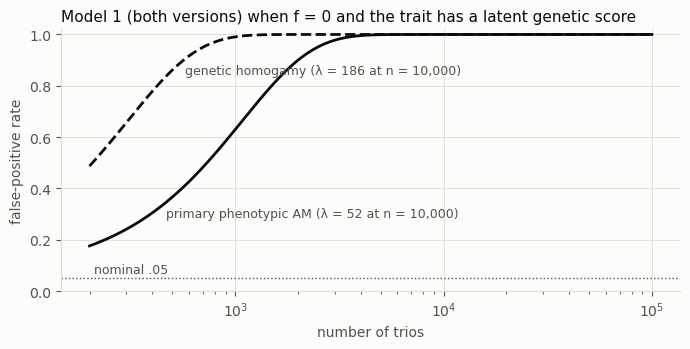

In [4]:
crit = stats.chi2.ppf(.95, 1)
n = np.logspace(np.log10(200), np.log10(100000), 200)
fig, ax = plt.subplots(figsize=(7, 3.6))
h0 = pop[(pop.f == 0) & (pop.model == "M1")].set_index("cond")
for cond, style, at in [("primary_latent_f000", "-", .3), ("genetic_latent_f000", "--", .85)]:
    lam10k = max(h0.loc[cond, "LRT"], 0)
    r = stats.ncx2.sf(crit, 1, lam10k * n / 10000)
    ax.plot(n, r, style, color=INK, lw=2)
    i = np.searchsorted(r, at)
    ax.annotate(f"{MLAB[h0.loc[cond, 'mating']]} (λ = {lam10k:.0f} at n = 10,000)", (n[i], r[i]),
                xytext=(10, 0), textcoords="offset points", color=INK2, fontsize=9, va="center")
ax.axhline(.05, color=INK2, lw=1, ls=":"); ax.text(210, .07, "nominal .05", color=INK2, fontsize=9)
ax.set_xscale("log"); ax.set_ylim(0, 1.02)
ax.set_xlabel("number of trios"); ax.set_ylabel("false-positive rate")
ax.set_title("Model 1 (both versions) when f = 0 and the trait has a latent genetic score", loc="left", fontsize=11)
plt.tight_layout(); plt.show()

## 2. Type I error: true f = 0

A valid test rejects about 5% of the time. With 10 datasets per cell a rate of 0–0.2 is consistent with 0.05, so look for the pattern, not for single cells.

**Model 2 Cascade** rejected 7 of 160 times (4.4%), with no condition standing out.

**Both Model 1 versions** rejected in all 40 datasets that have a latent genetic score and primary AM or genetic homogamy, at both n = 2,000 and n = 10,000. Their mean LRT there, about 10–34 at n = 2,000 and 48–181 at n = 10,000, matches the population λ scaled to n. In the other non-social conditions (random mating, and primary AM or genetic homogamy without a latent score), they rejected 2 of 80 times.

The chart below plots each rejection rate with its 95% interval. The second chart shows the population false-positive rate of Model 1 as a function of the number of trios.

In [5]:
def rates(df):
    g = df.groupby(["f", "n", "mating", "latent", "model"], sort=False)
    r = g.agg(datasets=("p", lambda x: x.notna().sum()), rejections=("sig", "sum"), mean_LRT=("LRT", "mean")).reset_index()
    r["rate"] = r.rejections / r.datasets
    r["lo"], r["hi"] = wilson(r.rejections, r.datasets)
    return r

h0 = rates(mc[mc.f == 0])
t = h0.copy()
t["condition"] = [condLabel(m, l) for m, l in zip(t.mating, t.latent)]
t["cell"] = [f"{r:.3f} [{lo:.3f}, {hi:.3f}]" for r, lo, hi in zip(t.rate, t.lo, t.hi)]
tab = t.pivot_table(index=["n", "condition"], columns="model", values="cell", aggfunc="first", sort=False)[MODELS]
tab.columns = [LABEL[m] for m in MODELS]
print("Rejection rate of f = 0 when f = 0 (alpha = .05), with Wilson 95% CI")
display(tab)
lt = t.pivot_table(index=["n", "condition"], columns="model", values="mean_LRT", sort=False)[MODELS]
lt.columns = [LABEL[m] for m in MODELS]
print("Mean LRT statistic (chi2_1 has mean 1)")
display(lt.round(2))

Rejection rate of f = 0 when f = 0 (alpha = .05), with Wilson 95% CI


Model 2 Cascade       Model 1 Cascade               Model 1
n     condition                                                                                                      
2000  random mating, PGS = all heritability          0.000 [0.000, 0.278]  0.100 [0.018, 0.404]  0.100 [0.018, 0.404]
      primary phenotypic AM, PGS = all heritability  0.100 [0.018, 0.404]  0.000 [0.000, 0.278]  0.000 [0.000, 0.278]
      genetic homogamy, PGS = all heritability       0.000 [0.000, 0.278]  0.000 [0.000, 0.278]  0.000 [0.000, 0.278]
      social homogamy, PGS = all heritability        0.000 [0.000, 0.278]  0.200 [0.057, 0.510]  0.000 [0.000, 0.278]
      random mating, latent genetic score            0.000 [0.000, 0.278]  0.000 [0.000, 0.278]  0.000 [0.000, 0.278]
      primary phenotypic AM, latent genetic score    0.000 [0.000, 0.278]  1.000 [0.722, 1.000]  1.000 [0.722, 1.000]
      genetic homogamy, latent genetic score         0.000 [0.000, 0.278]  1.000 [0.722, 1.000]  1.000 [0.722, 1.000]
      social homogamy, latent genetic score          0.100 [0.018, 0.404]  0.200 [0.057, 0.510]  0.000 [0.000, 0.278]
10000 random mating, PGS = all heritability          0.100 [0.018, 0.404]  0.100 [0.018, 0.404]  0.100 [0.018, 0.404]
      primary phenotypic AM, PGS = all heritability  0.000 [0.000, 0.278]  0.000 [0.000, 0.278]  0.000 [0.000, 0.278]
      genetic homogamy, PGS = all heritability       0.200 [0.057, 0.510]  0.000 [0.000, 0.278]  0.000 [0.000, 0.278]
      social homogamy, PGS = all heritability        0.000 [0.000, 0.278]  0.100 [0.018, 0.404]  0.000 [0.000, 0.278]
      random mating, latent genetic score            0.000 [0.000, 0.278]  0.000 [0.000, 0.278]  0.000 [0.000, 0.278]
      primary phenotypic AM, latent genetic score    0.000 [0.000, 0.278]  1.000 [0.722, 1.000]  1.000 [0.722, 1.000]
      genetic homogamy, latent genetic score         0.100 [0.018, 0.404]  1.000 [0.722, 1.000]  1.000 [0.722, 1.000]
      social homogamy, latent genetic score          0.100 [0.018, 0.404]  0.200 [0.057, 0.510]  0.100 [0.018, 0.404]

Mean LRT statistic (chi2_1 has mean 1)


Model 2 Cascade  Model 1 Cascade  Model 1
n     condition                                                                               
2000  random mating, PGS = all heritability                     0.87             1.02     1.02
      primary phenotypic AM, PGS = all heritability             1.00             1.44     1.44
      genetic homogamy, PGS = all heritability                  1.02             0.64     0.64
      social homogamy, PGS = all heritability                   0.43             1.20     0.36
      random mating, latent genetic score                       1.00             0.68     0.68
      primary phenotypic AM, latent genetic score               0.79             9.79     9.79
      genetic homogamy, latent genetic score                    0.96            33.75    33.75
      social homogamy, latent genetic score                     1.05             2.30     1.12
10000 random mating, PGS = all heritability                     1.17             1.14     1.14
      primary phenotypic AM, PGS = all heritability             0.43             0.70     0.70
      genetic homogamy, PGS = all heritability                  1.68             1.61     1.61
      social homogamy, PGS = all heritability                   0.75             2.05     0.83
      random mating, latent genetic score                       0.84             0.93     0.93
      primary phenotypic AM, latent genetic score               0.48            47.88    47.88
      genetic homogamy, latent genetic score                    0.70           180.82   180.82
      social homogamy, latent genetic score                     1.40             2.32     1.65

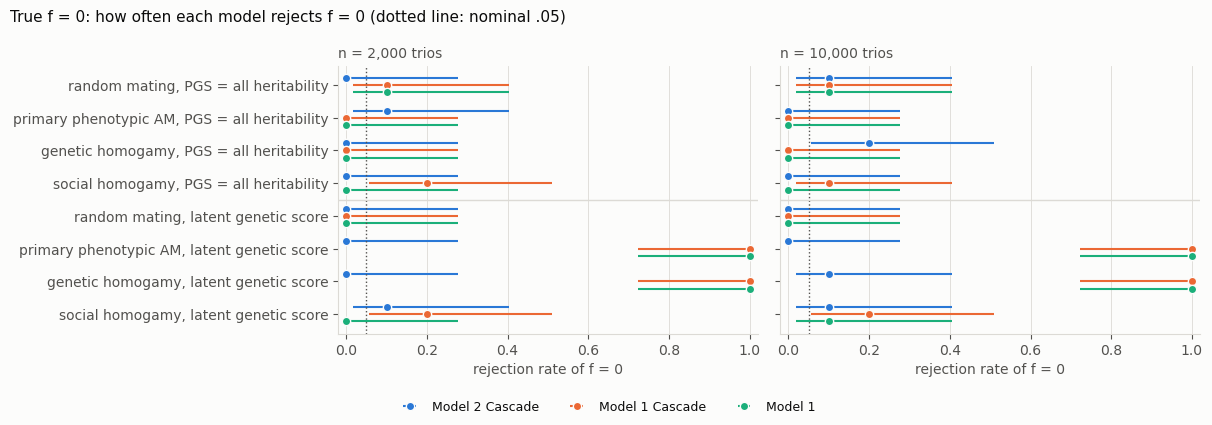

In [6]:
def dotplot(r, title, ref=None):
    ns = sorted(r.n.unique())
    conds = [(m, l) for l in (False, True) for m in MATING]
    fig, axes = plt.subplots(1, len(ns), figsize=(5.2 * len(ns) + 1.8, 4.2), sharey=True, squeeze=False)
    for ax, nn in zip(axes[0], ns):
        for j, m in enumerate(MODELS):
            s = r[(r.n == nn) & (r.model == m)].set_index(["mating", "latent"]).reindex(conds)
            y = np.arange(len(conds)) + (j - 1) * .22
            ax.errorbar(s.rate, y, xerr=[(s.rate - s.lo).clip(lower=0), (s.hi - s.rate).clip(lower=0)], fmt="o", ms=6, color=COLOR[m],
                        ecolor=COLOR[m], elinewidth=1.5, capsize=0, label=LABEL[m], mec="#fcfcfb", mew=1)
        if ref is not None:
            ax.axvline(ref, color=INK2, lw=1, ls=":")
        ax.set_xlim(-.02, 1.02); ax.set_title(f"n = {nn:,} trios", loc="left", fontsize=10, color=INK2)
        ax.set_xlabel("rejection rate of f = 0"); ax.grid(axis="y", visible=False)
        ax.axhline(3.5, color=RULE, lw=1)
    axes[0][0].set_yticks(range(len(conds)), [condLabel(m, l) for m, l in conds]); axes[0][0].invert_yaxis()
    h, l = axes[0][0].get_legend_handles_labels()
    fig.suptitle(title, x=.01, ha="left", fontsize=11)
    plt.tight_layout(rect=(0, .07, 1, 1))
    fig.legend(h, l, loc="lower center", ncol=3, fontsize=9)
    plt.show()

dotplot(h0, "True f = 0: how often each model rejects f = 0 (dotted line: nominal .05)", ref=.05)

### Are the p-values uniform where the test should be valid?

This is a QQ plot of the f = 0 p-values, pooled over the conditions where the population λ is 0. Points on the dotted line mean the test is calibrated.

- **Model 2 Cascade** and the original **Model 1** follow the line, including under social homogamy.
- **Model 1 Cascade's social-homogamy points lie above the line.** That is the problem described next.

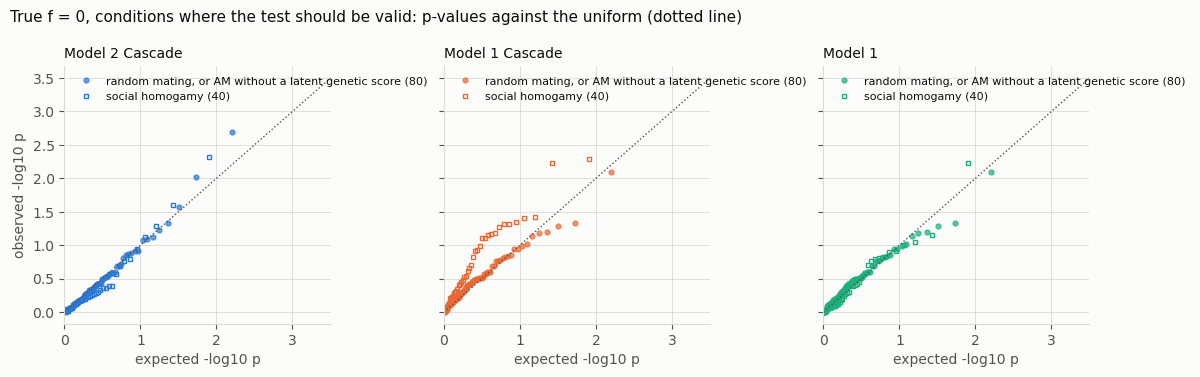

In [7]:
valid = ~((mc.latent) & (mc.mating.isin(["primary", "genetic"])))
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for ax, m in zip(axes, MODELS):
    for (sub, lab, style) in [(valid & (mc.mating != "social"), "random mating, or AM without a latent genetic score", "o"),
                              (mc.mating == "social", "social homogamy", "s")]:
        p = np.sort(mc[(mc.f == 0) & (mc.model == m) & sub].p.dropna().values)
        e = (np.arange(1, len(p) + 1) - .5) / len(p)
        ax.plot(-np.log10(e), -np.log10(p), style, ms=3.5, color=COLOR[m], alpha=.7 if style == "o" else 1,
                mfc=COLOR[m] if style == "o" else "none", label=f"{lab} ({len(p)})")
    lim = 3.5
    ax.plot([0, lim], [0, lim], color=INK2, lw=1, ls=":")
    ax.set_xlim(0, lim)
    ax.set_title(LABEL[m], loc="left", fontsize=10)
    ax.set_xlabel("expected -log10 p"); ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("observed -log10 p")
fig.suptitle("True f = 0, conditions where the test should be valid: p-values against the uniform (dotted line)",
             x=.01, ha="left", fontsize=11)
plt.tight_layout(); plt.show()

In [8]:
s = mc[(mc.model == "M1_Cascade") & (mc.mating == "social") & (mc.f == 0)]
rows = []
for (l, nn), g in s.groupby(["latent", "n"]):
    rows.append({"condition": condLabel("social", l), "n": nn, "datasets": len(g), "mean LRT": g.LRT.mean(),
                 "reject vs chi2_1 (3.84)": (g.LRT > stats.chi2.ppf(.95, 1)).mean(),
                 "reject vs chi2_2 (5.99)": (g.LRT > stats.chi2.ppf(.95, 2)).mean()})
print("Model 1 Cascade under social homogamy, true f = 0: the LRT compared with chi2_1 and chi2_2")
display(pd.DataFrame(rows).set_index(["condition", "n"]).round(3))

Model 1 Cascade under social homogamy, true f = 0: the LRT compared with chi2_1 and chi2_2


datasets  mean LRT  reject vs chi2_1 (3.84)  reject vs chi2_2 (5.99)
condition                               n                                                                          
social homogamy, PGS = all heritability 2000         10     1.196                      0.2                      0.0
                                        10000        10     2.054                      0.1                      0.0
social homogamy, latent genetic score   2000         10     2.298                      0.2                      0.1
                                        10000        10     2.320                      0.2                      0.1

**Model 1 Cascade under social homogamy.** Under social homogamy spouses assort on F + E, so in Model 1 Cascade the copath µ affects the data only through vertical transmission (w and VF), and those terms vanish when f = 0. The f = 0 model therefore loses two parameters, f and µ, not one, and the LRT behaves like a 2-df statistic compared with a 1-df critical value.

The evidence is consistent with this: the mean LRT is 1.97 (χ²₂ has mean 2) and the test rejected 7 of 40 times (17.5%), close to P(χ²₂ > 3.84) = 0.147.

The population λ is 0 here, because the test is centred correctly; it is the null distribution that is wrong. Comparing this model's LRT with χ²₂ (5.99) would restore the 5% level. The original Model 1 does not have the problem: its µ still acts through the PGS covariances, so it rejected 1 of 40 times. Model 2 Cascade doesn't either, since it sees µ in the spouses' phenotypic covariance.

## 3. Power: true f > 0

At f = .15 and n = 10,000 every model rejects in every condition, so the decisions agree.

At f = .05, Model 2 Cascade has much less power than Model 1. Its expected power at n = 10,000 is 0.22 under genetic homogamy with a latent score, 0.55 under primary AM with a latent score, and 0.66 under genetic homogamy without one. Model 1's is about 1.00 in all three, in part because Model 1 overestimates f there.

Model 2 pays for its correct specification: it estimates the latent genetic path a and the mating mechanism, and that information has to come from the same data. So even with two valid tests, "significant under one model means significant under the other" cannot be expected at modest effect sizes.

Rejection rate of f = 0 when f > 0 (power), n = 10,000, with Wilson 95% CI


Model 2 Cascade       Model 1 Cascade               Model 1
f    condition                                                                                                      
0.05 random mating, PGS = all heritability          1.000 [0.722, 1.000]  1.000 [0.722, 1.000]  1.000 [0.722, 1.000]
     primary phenotypic AM, PGS = all heritability  1.000 [0.722, 1.000]  1.000 [0.722, 1.000]  1.000 [0.722, 1.000]
     genetic homogamy, PGS = all heritability       0.500 [0.237, 0.763]  1.000 [0.722, 1.000]  1.000 [0.722, 1.000]
     social homogamy, PGS = all heritability        1.000 [0.722, 1.000]  1.000 [0.722, 1.000]  1.000 [0.722, 1.000]
     random mating, latent genetic score            0.800 [0.490, 0.943]  0.600 [0.313, 0.832]  0.600 [0.313, 0.832]
     primary phenotypic AM, latent genetic score    0.600 [0.313, 0.832]  1.000 [0.722, 1.000]  1.000 [0.722, 1.000]
     genetic homogamy, latent genetic score         0.500 [0.237, 0.763]  1.000 [0.722, 1.000]  1.000 [0.722, 1.000]
     social homogamy, latent genetic score          0.800 [0.490, 0.943]  0.900 [0.596, 0.982]  0.900 [0.596, 0.982]
0.15 random mating, PGS = all heritability          1.000 [0.722, 1.000]  1.000 [0.722, 1.000]  1.000 [0.722, 1.000]
     primary phenotypic AM, PGS = all heritability  1.000 [0.722, 1.000]  1.000 [0.722, 1.000]  1.000 [0.722, 1.000]
     genetic homogamy, PGS = all heritability       1.000 [0.722, 1.000]  1.000 [0.722, 1.000]  1.000 [0.722, 1.000]
     social homogamy, PGS = all heritability        1.000 [0.722, 1.000]  1.000 [0.722, 1.000]  1.000 [0.722, 1.000]
     random mating, latent genetic score            1.000 [0.722, 1.000]  1.000 [0.722, 1.000]  1.000 [0.722, 1.000]
     primary phenotypic AM, latent genetic score    1.000 [0.722, 1.000]  1.000 [0.722, 1.000]  1.000 [0.722, 1.000]
     genetic homogamy, latent genetic score         1.000 [0.722, 1.000]  1.000 [0.722, 1.000]  1.000 [0.722, 1.000]
     social homogamy, latent genetic score          1.000 [0.722, 1.000]  1.000 [0.722, 1.000]  1.000 [0.722, 1.000]

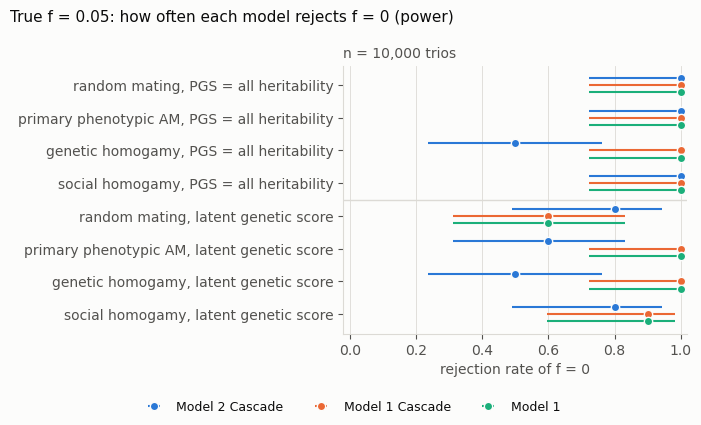

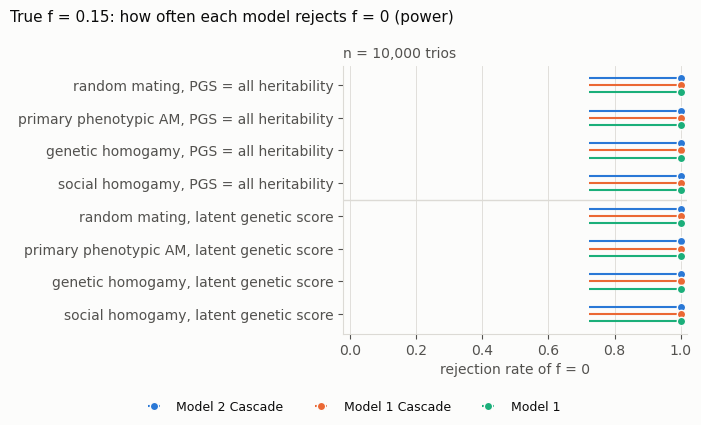

In [9]:
h1 = rates(mc[mc.f > 0])
t = h1.copy()
t["condition"] = [condLabel(m, l) for m, l in zip(t.mating, t.latent)]
t["cell"] = [f"{r:.3f} [{lo:.3f}, {hi:.3f}]" for r, lo, hi in zip(t.rate, t.lo, t.hi)]
tab = t.pivot_table(index=["f", "condition"], columns="model", values="cell", aggfunc="first", sort=False)[MODELS]
tab.columns = [LABEL[m] for m in MODELS]
print("Rejection rate of f = 0 when f > 0 (power), n = 10,000, with Wilson 95% CI")
display(tab)
for fv in sorted(h1.f.unique()):
    dotplot(h1[h1.f == fv], f"True f = {fv}: how often each model rejects f = 0 (power)")

## 4. The claim as stated: do Model 1 and Model 2 reach the same decision?

Each dataset is cross-classified by whether f is significant under Model 2 Cascade and under each Model 1 version.

The decisions disagree mainly in two situations:

- **f = 0 with a latent score under primary AM or genetic homogamy.** Model 1 is significant and Model 2 is not, in 39 of 40 datasets. Model 1 is wrong here.
- **f = .05.** Model 1 is significant and Model 2 is not, because of the power difference. Here Model 1 is right, but for partly the wrong reason (an inflated estimate).

The remaining disagreements are the scattered 5%-level false positives of each test.

In [10]:
w = mc.pivot_table(index=["f", "n", "mating", "latent", "rep"], columns="model", values="sig", aggfunc="first").dropna()
rows = []
for (fv, nn, m, l), g in w.groupby(level=[0, 1, 2, 3], sort=False):
    for other in ["M1_Cascade", "M1"]:
        a, b = g["M2_Cascade"].astype(bool), g[other].astype(bool)
        rows.append({"true f": fv, "n": nn, "condition": condLabel(m, l), "Model 1 version": LABEL[other],
                     "agree": (a == b).mean(), "only Model 1 significant": (~a & b).mean(),
                     "only Model 2 significant": (a & ~b).mean(), "datasets": len(g)})
agree = pd.DataFrame(rows)
order = [condLabel(m, l) for l in (False, True) for m in MATING]
agree["condition"] = pd.Categorical(agree.condition, order)
wide = agree.pivot_table(index=["true f", "n", "condition"], columns="Model 1 version", observed=True,
                         values=["agree", "only Model 1 significant", "only Model 2 significant"])
wide = wide.swaplevel(0, 1, axis=1).sort_index(axis=1, level=0)
print("Share of datasets where Model 2 Cascade and each Model 1 version reach the same decision about f (alpha = .05)")
display(wide.round(3))

Share of datasets where Model 2 Cascade and each Model 1 version reach the same decision about f (alpha = .05)


Model 1 version                                            Model 1                                                   Model 1 Cascade                           \
                                                             agree only Model 1 significant only Model 2 significant           agree only Model 1 significant   
true f n     condition                                                                                                                                          
0.00   2000  random mating, PGS = all heritability             0.9                      0.1                      0.0             0.9                      0.1   
             primary phenotypic AM, PGS = all heritability     0.9                      0.0                      0.1             0.9                      0.0   
             genetic homogamy, PGS = all heritability          1.0                      0.0                      0.0             1.0                      0.0   
             social homogamy, PGS = all heritability           1.0                      0.0                      0.0             0.8                      0.2   
             random mating, latent genetic score               1.0                      0.0                      0.0             1.0                      0.0   
             primary phenotypic AM, latent genetic score       0.0                      1.0                      0.0             0.0                      1.0   
             genetic homogamy, latent genetic score            0.0                      1.0                      0.0             0.0                      1.0   
             social homogamy, latent genetic score             0.9                      0.0                      0.1             0.9                      0.1   
       10000 random mating, PGS = all heritability             1.0                      0.0                      0.0             1.0                      0.0   
             primary phenotypic AM, PGS = all heritability     1.0                      0.0                      0.0             1.0                      0.0   
             genetic homogamy, PGS = all heritability          0.8                      0.0                      0.2             0.8                      0.0   
             social homogamy, PGS = all heritability           1.0                      0.0                      0.0             0.9                      0.1   
             random mating, latent genetic score               1.0                      0.0                      0.0             1.0                      0.0   
             primary phenotypic AM, latent genetic score       0.0                      1.0                      0.0             0.0                      1.0   
             genetic homogamy, latent genetic score            0.1                      0.9                      0.0             0.1                      0.9   
             social homogamy, latent genetic score             1.0                      0.0                      0.0             0.9                      0.1   
0.05   10000 random mating, PGS = all heritability             1.0                      0.0                      0.0             1.0                      0.0   
             primary phenotypic AM, PGS = all heritability     1.0                      0.0                      0.0             1.0                      0.0   
             genetic homogamy, PGS = all heritability          0.5                      0.5                      0.0             0.5                      0.5   
             social homogamy, PGS = all heritability           1.0                      0.0                      0.0             1.0                      0.0   
             random mating, latent genetic score               0.8                      0.0                      0.2             0.8                      0.0   
             primary phenotypic AM, latent genetic score       0.6                      0.4                      0.0             0.6    

## 5. Estimates of f

Medians over the 10 datasets per cell agree with the population values in Section 1:

- Model 2 Cascade is unbiased.
- Both Model 1 versions roughly double or triple f under primary AM and genetic homogamy when there is a latent genetic score.
- Model 1 also overestimates f slightly under social homogamy.

Model 1 Cascade under social homogamy occasionally converges to an implausible f (|f| > 1). These are genuine optima of its likelihood, confirmed by the multistart, not convergence failures. They are another symptom of µ being identified only through f.

In [11]:
e = mc.groupby(["f", "mating", "latent", "model"], sort=False).agg(mean_f=("f_est", "mean"), sd_f=("f_est", "std"),
                                                                   mean_SE=("f_SE", "mean")).reset_index()
e["condition"] = [condLabel(m, l) for m, l in zip(e.mating, e.latent)]
med = mc.groupby(["f", "mating", "latent", "model"], sort=False).f_est.median().rename("median_f").reset_index()
e = e.merge(med, on=["f", "mating", "latent", "model"])
tab = e.pivot_table(index=["f", "condition"], columns="model", values="median_f", sort=False)[MODELS]
tab.columns = [LABEL[m] for m in MODELS]
print("Median estimate of f over the Monte Carlo datasets (true f in the first index level)")
display(tab.round(3))
far = mc[mc.f_est.abs() > 1].groupby(["model", "mating"]).size()
print("Datasets with |f estimate| > 1, by model and mating type:"); display(far.to_frame("datasets"))

Median estimate of f over the Monte Carlo datasets (true f in the first index level)


Model 2 Cascade  Model 1 Cascade  Model 1
f    condition                                                                               
0.00 random mating, PGS = all heritability                   -0.003            0.001    0.001
     primary phenotypic AM, PGS = all heritability            0.001            0.006    0.006
     genetic homogamy, PGS = all heritability                -0.013            0.004    0.003
     social homogamy, PGS = all heritability                 -0.008           -0.000   -0.001
     random mating, latent genetic score                     -0.008           -0.015   -0.015
     primary phenotypic AM, latent genetic score             -0.006            0.087    0.087
     genetic homogamy, latent genetic score                   0.004            0.191    0.140
     social homogamy, latent genetic score                   -0.003           -0.002    0.002
0.05 random mating, PGS = all heritability                    0.050            0.051    0.051
     primary phenotypic AM, PGS = all heritability            0.048            0.052    0.052
     genetic homogamy, PGS = all heritability                 0.035            0.051    0.045
     social homogamy, PGS = all heritability                  0.046            0.054    0.053
     random mating, latent genetic score                      0.045            0.042    0.042
     primary phenotypic AM, latent genetic score              0.058            0.152    0.152
     genetic homogamy, latent genetic score                   0.067            0.247    0.186
     social homogamy, latent genetic score                    0.050            0.048    0.052
0.15 random mating, PGS = all heritability                    0.145            0.146    0.146
     primary phenotypic AM, PGS = all heritability            0.147            0.148    0.148
     genetic homogamy, PGS = all heritability                 0.146            0.153    0.137
     social homogamy, PGS = all heritability                  0.147            0.148    0.153
     random mating, latent genetic score                      0.147            0.154    0.154
     primary phenotypic AM, latent genetic score              0.143            0.236    0.236
     genetic homogamy, latent genetic score                   0.159            0.331    0.257
     social homogamy, latent genetic score                    0.145            0.147    0.159

Datasets with |f estimate| > 1, by model and mating type:


,,datasets
model,mating,
M1_Cascade,social,3


## 6. Fit diagnostics

No fit failed, and no LRT is negative. *Reseeded* counts the datasets where the first free fit ended worse than the f = 0 fit, or with a bad status code, and was refit from the f = 0 solution.

Eight Model 2 Cascade free fits and nine f = 0 fits (across the three models) still end with status 6: OpenMx could not confirm the first-order optimality conditions. Each is the best −2LL found over all restarts. None of them changes a decision. The f = 0 datasets among them have LRTs of 0.01–0.2, and the f > 0 datasets are significant by a wide margin.

In [12]:
dg = mc.groupby("model").agg(fits=("model", "size"), failed=("p", lambda x: x.isna().sum()),
                             negative_LRT=("LRT", lambda x: (x < -1e-4).sum()),
                             reseeded=("reseeded", "sum"),
                             status_free_not_0_or_1=("status_free", lambda x: (~x.isin([0, 1])).sum()),
                             status_f0_not_0_or_1=("status_f0", lambda x: (~x.isin([0, 1])).sum()))
dg.index = [LABEL[m] for m in dg.index]
display(dg)
print(f"median seconds per dataset (all three models): {mc.drop_duplicates(['cond', 'n', 'rep']).time_sec.median():.1f}")

,fits,failed,negative_LRT,reseeded,status_free_not_0_or_1,status_f0_not_0_or_1
Model 1,320,0,0,0,0,4
Model 1 Cascade,320,0,0,0,0,3
Model 2 Cascade,320,0,0,10,8,2


median seconds per dataset (all three models): 10.9


## Conclusion

**The claim holds only when Model 1's assumptions hold.** The f = 0 test from Model 1 is valid with random mating or with a PGS that captures all of the heritability. The original Model 1 is also valid under social homogamy, though its Cascade version needs a 2-df reference distribution there.

It fails in the most realistic case for current PGS: a PGS that captures only part of the heritability, with primary AM or genetic homogamy. There Model 1 finds vertical transmission when there is none, with near-certainty at any sample size above a few thousand trios. A significant f from Model 1 in such data is not evidence of vertical transmission.

**The test from Model 2 Cascade is valid in every condition**, but less powerful. Agreement between the two models is therefore not guaranteed even when both are valid.

**Practical implication.** Test f with Model 2 Cascade (or another model that includes the latent genetic score) whenever AM is plausible. If Model 1 is used, report it as valid only under random mating, under social homogamy, or when the PGS is close to the full heritability.

**Limits of this check.**

- Equilibrium and a continuous trait only.
- One set of generating values (mate correlation .4, PGS share of the genetic variance .4).
- 10 Monte Carlo datasets per cell.

The population λ gives the precise rates for these values. A smaller PGS share or stronger AM increases the PGS–latent covariance i, so Model 1's bias would likely be larger (not tested here).